# 📊 Customer Churn Analysis
### Why Customers Leave — and What to Do About It

---

**Business Question**
Which customers are most likely to churn, and what can the company do to retain them?

**Dataset**
Telco Customer Churn — 7,043 customers, 21 features (IBM sample dataset)

---

## Executive Summary

| | |
|---|---|
| 🔑 **Key Finding** | Month-to-month customers churn at **42.7%**, vs. just **2.8%** for two-year contracts — a ~15x gap, and the strongest churn driver identified in this analysis. |
| 🤖 **Model Performance** | A class-weighted Random Forest model achieves **65.4% recall**, correctly identifying nearly two-thirds of customers who go on to churn. |
| 💰 **Business Impact** | Of ~373 churners in the test set, the model flags **244** for proactive outreach — customers who would otherwise receive no warning before cancelling. |
| ✅ **Recommendation** | Prioritize converting month-to-month customers to annual contracts within their first 3 months, and deploy the churn model monthly to flag at-risk customers before they cancel. |

---

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.shape

(7043, 21)

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing values after conversion:", df['TotalCharges'].isnull().sum())
print("New dtype:", df['TotalCharges'].dtype)

Missing values after conversion: 11
New dtype: float64


In [7]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("Missing values now:", df['TotalCharges'].isnull().sum())

Missing values now: 0


In [8]:
df = df.drop('customerID', axis=1)
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 22


In [9]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6491,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20,Yes
6764,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.20,69.20,Yes
4495,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10,Yes
6267,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.10,Yes
5522,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
5759,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,Yes
542,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1491,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
5170,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No
6774,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


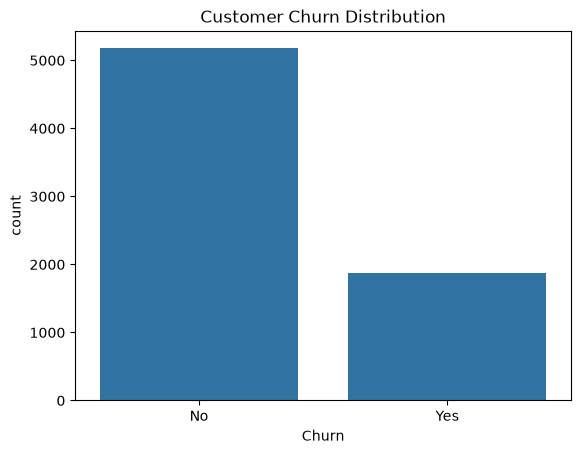

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

churn_rate = df['Churn'].value_counts(normalize=True) * 100                              # Overall churn rate
print(churn_rate)

sns.countplot(data=df, x='Churn')
plt.title('Customer Churn Distribution')
plt.show()

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


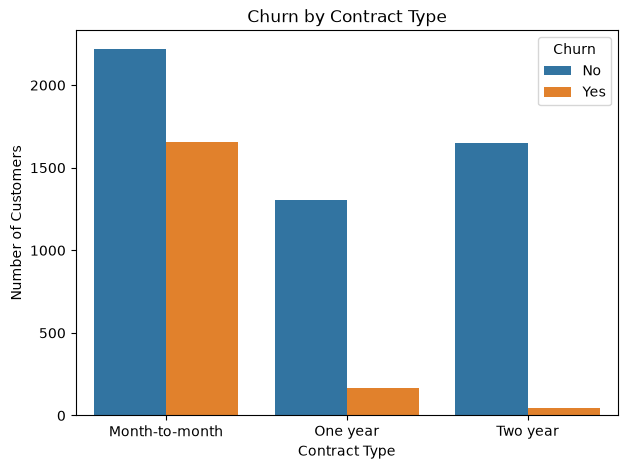

In [11]:
contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100
print(contract_churn)

plt.figure(figsize=(7,5))
sns.countplot(data=df, x='Contract', hue='Churn')                                  #Churn by contract type
plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')
plt.savefig('../outputs/churn_by_contract.png', dpi=300, bbox_inches='tight')
plt.show()

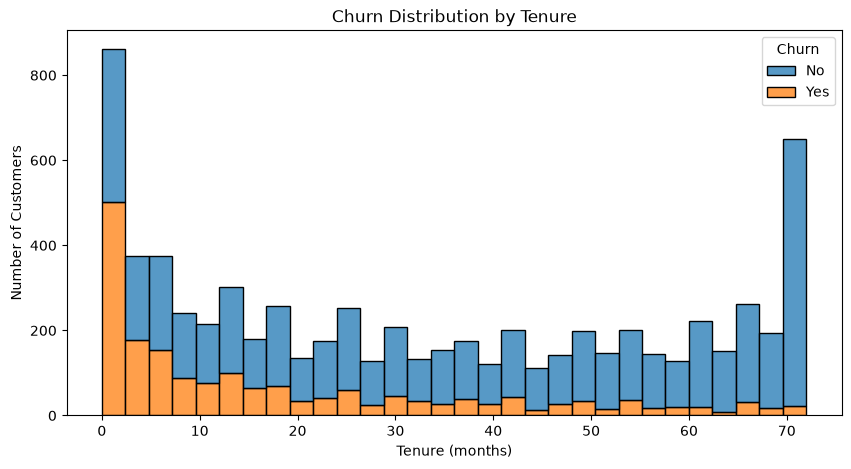

In [12]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, multiple='stack')
plt.title('Churn Distribution by Tenure')                                              #churn by tenure
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.savefig('../outputs/churn_by_tenure.png', dpi=300, bbox_inches='tight')
plt.show()

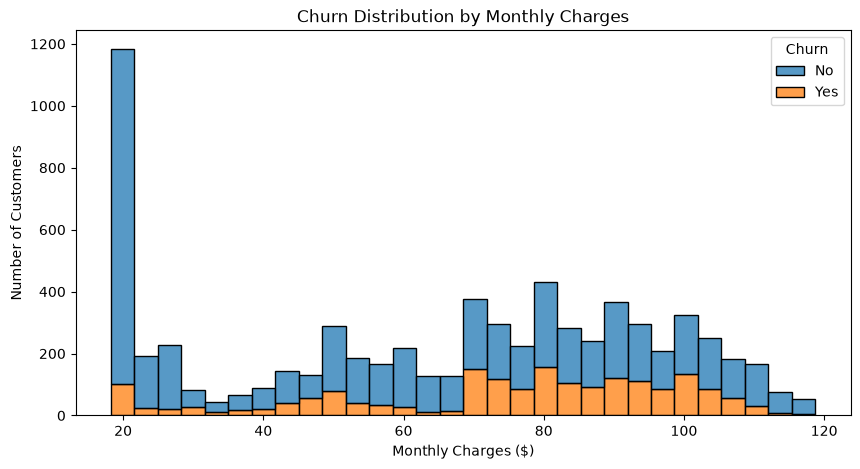

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, multiple='stack')
plt.title('Churn Distribution by Monthly Charges')                                   #churn by monthly charges
plt.xlabel('Monthly Charges ($)')
plt.ylabel('Number of Customers')
plt.show()

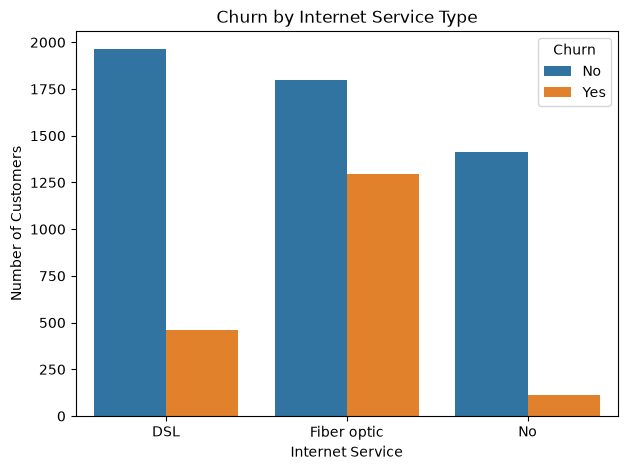

In [14]:
plt.figure(figsize=(7,5))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title('Churn by Internet Service Type')                          #churn by internet service
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')
plt.show()

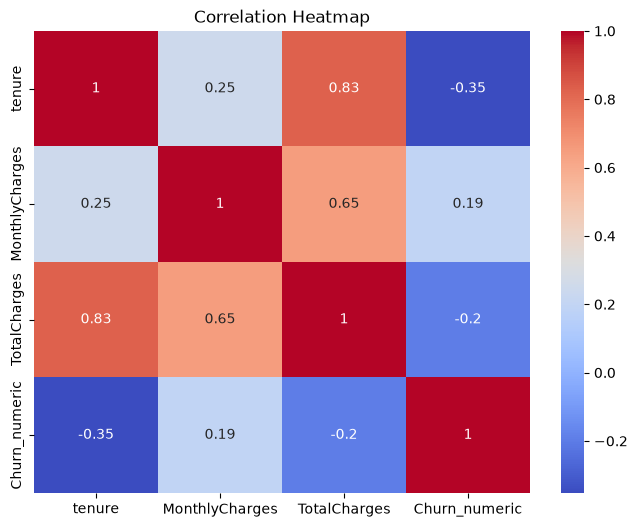

In [15]:
df_corr = df.copy()
df_corr['Churn_numeric'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(8,6))                 #Convert Churn to numeric temporarily just for this correlation check     
sns.heatmap(df_corr[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_numeric']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## Key EDA Insights

1. **Contract type is the strongest churn driver.** Month-to-month customers churn at 42.7%, 
   vs 11.3% for one-year and just 2.8% for two-year contracts — a ~15x difference.

2. **Early tenure is the highest-risk window.** Churn is heavily concentrated in the first 
   0–3 months of a customer relationship, tapering off sharply after that.

3. **Higher monthly charges correlate with more churn.** Customers paying above ~$70/month 
   show a noticeably higher churn proportion than lower-tier customers.

4. **Fiber optic customers churn 2x+ more than DSL customers** (~42% vs ~19%), despite being 
   the premium service — suggesting a price-to-value gap worth investigating.

5. **Tenure is the strongest numeric predictor of churn** (correlation: -0.35). Note: tenure 
   and TotalCharges are highly correlated (0.83) — only one should be used in modeling to 
   avoid multicollinearity.

In [16]:
def risk_score(row):
    score = 0
    if row['Contract'] == 'Month-to-month':
        score += 50
    elif row['Contract'] == 'One year':
        score += 20
    else:
        score += 5

    if row['tenure'] <= 3:
        score += 30
    elif row['tenure'] <= 12:
        score += 15                                                 #Create a basic risk score

    if row['MonthlyCharges'] > 70:
        score += 20

    return score

df['RiskScore'] = df.apply(risk_score, axis=1)
df[['tenure', 'Contract', 'MonthlyCharges', 'RiskScore', 'Churn']].head(10)

,tenure,Contract,MonthlyCharges,RiskScore,Churn
0,1,Month-to-month,29.85,80,No
1,34,One year,56.95,20,No
2,2,Month-to-month,53.85,80,Yes
3,45,One year,42.30,20,No
4,2,Month-to-month,70.70,100,Yes
5,8,Month-to-month,99.65,85,Yes
6,22,Month-to-month,89.10,70,No
7,10,Month-to-month,29.75,65,No
8,28,Month-to-month,104.80,70,Yes
9,62,One year,56.15,20,No


In [17]:
def risk_segment(score):
    if score >= 70:
        return 'High Risk'
    elif score >= 40:
        return 'Medium Risk'
    else:
        return 'Low Risk'                                           #create risk segment

df['RiskSegment'] = df['RiskScore'].apply(risk_segment)

# Check how many customers fall into each segment
print(df['RiskSegment'].value_counts())

# Sanity check: does actual churn rate increase as risk segment increases?
print(df.groupby('RiskSegment')['Churn'].value_counts(normalize=True).unstack() * 100)

RiskSegment
High Risk      2742
Low Risk       2426
Medium Risk    1875
Name: count, dtype: int64
Churn               No        Yes
RiskSegment                      
High Risk    48.322392  51.677608
Low Risk     96.413850   3.586150
Medium Risk  80.533333  19.466667


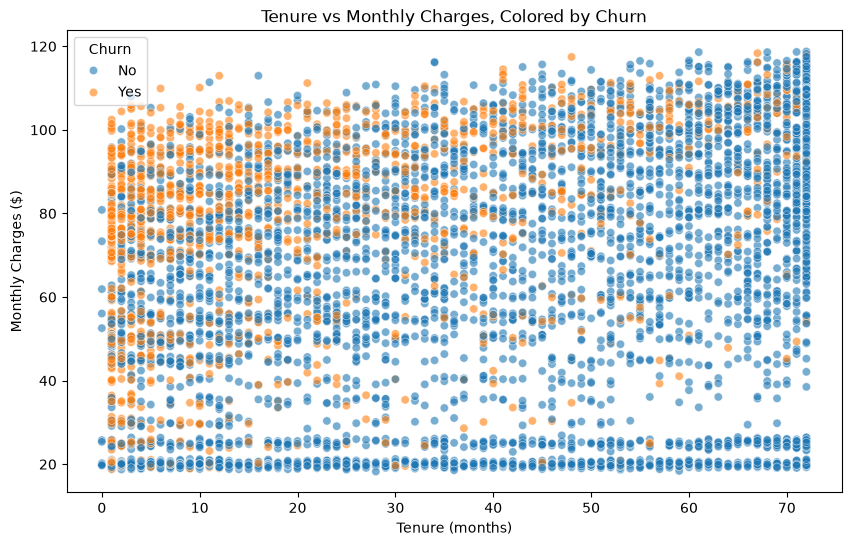

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='tenure', y='MonthlyCharges', hue='Churn', alpha=0.6)
plt.title('Tenure vs Monthly Charges, Colored by Churn')                 # Visualize the segments
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges ($)')
plt.savefig('../outputs/risk_segment_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
df_model = df.drop(['RiskScore', 'RiskSegment'], axis=1)

df_model['Churn'] = df_model['Churn'].map({'Yes': 1, 'No': 0})
                                                                   #preparing the data
df_model = pd.get_dummies(df_model, drop_first=True)

df_model.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [20]:
df_model.shape

(7043, 31)

In [21]:
X = df_model.drop('Churn', axis=1)
y = df_model['Churn']
                                                   #spliting the data
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 30)
y shape: (7043,)


In [22]:
from sklearn.model_selection import train_test_split                      #train/test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
                                                      
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (5634, 30)
Test set size: (1409, 30)


In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)              #training the model
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [24]:
y_pred = model.predict(X_test)
                                           #making predictions
print(y_pred[:10])
print(y_test[:10].values)

[1 0 0 1 0 0 0 0 0 0]
[1 0 0 1 0 1 0 0 1 1]


In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))                    #evaluating performance
print("F1 Score:", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8218594748048261
Precision: 0.6871165644171779
Recall: 0.6005361930294906
F1 Score: 0.6409155937052933

Confusion Matrix:
[[934 102]
 [149 224]]


                           Feature  Coefficient
25               Contract_Two year    -1.388438
10     InternetService_Fiber optic     0.636985
24               Contract_One year    -0.630587
13              OnlineSecurity_Yes    -0.472207
7                 PhoneService_Yes    -0.448689
19                 TechSupport_Yes    -0.394434
26            PaperlessBilling_Yes     0.336836
28  PaymentMethod_Electronic check     0.325368
8   MultipleLines_No phone service     0.275508
23             StreamingMovies_Yes     0.223399


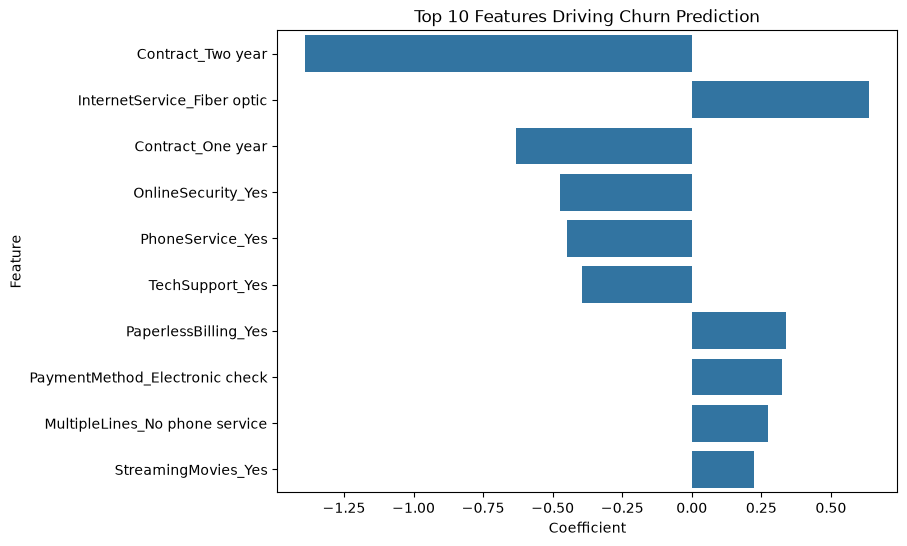

In [26]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(by='Coefficient', key=abs, ascending=False)

print(importance.head(10))                 #Feature importance

plt.figure(figsize=(8,6))
sns.barplot(data=importance.head(10), x='Coefficient', y='Feature')
plt.title('Top 10 Features Driving Churn Prediction')
plt.savefig('../outputs/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## Trying a Random Forest Model

Logistic Regression gave us a solid baseline (82% accuracy, 60% recall), but it can only 
capture simple, mostly linear relationships between features and churn. Random Forest builds 
many decision trees and combines their votes, which often captures more complex "if this AND 
that" patterns in customer behavior. Let's train one and compare it directly against our 
Logistic Regression results using the same metrics.

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)    #Training Random Forest
rf_model.fit(X_train, y_train)

print("Random Forest trained successfully")

Random Forest trained successfully


In [28]:
y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
                                                                     #predict and evaluate
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7849538679914834
Precision: 0.63671875
Recall: 0.43699731903485256
F1 Score: 0.5182829888712241

Confusion Matrix:
[[943  93]
 [210 163]]


## Model Comparison

| Metric | Logistic Regression | Random Forest |
|---|---|---|
| Accuracy | 82.2% | 78.5% |
| Precision | 68.7% | 63.7% |
| Recall | 60.1% | 43.7% |
| F1 Score | 64.1% | 51.8% |

**Logistic Regression outperformed Random Forest on every metric**, particularly recall — 
likely due to Random Forest's default settings being more conservative on the minority 
(churn) class given the dataset's ~73/27 class imbalance. **Logistic Regression is selected 
as the final model** for this project.

## Improving Random Forest with Class Weighting

Random Forest underperformed on recall, likely because it treated both classes equally 
despite the ~73/27 imbalance. Let's try `class_weight='balanced'`, which tells the model to 
pay proportionally more attention to the minority class (churned customers) during training, 
and see if that recovers the lost recall.

In [29]:
rf_balanced = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_balanced.fit(X_train, y_train)

y_pred_rf_balanced = rf_balanced.predict(X_test)
                                                                    #Retrain with class_weight='balanced'
print("Accuracy:", accuracy_score(y_test, y_pred_rf_balanced))
print("Precision:", precision_score(y_test, y_pred_rf_balanced)) 
print("Recall:", recall_score(y_test, y_pred_rf_balanced))
print("F1 Score:", f1_score(y_test, y_pred_rf_balanced))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_balanced))

Accuracy: 0.7892122072391767
Precision: 0.5922330097087378
Recall: 0.6541554959785523
F1 Score: 0.621656050955414

Confusion Matrix:
[[868 168]
 [129 244]]


## Model Comparison (Updated)

| Metric | Logistic Regression | Random Forest (default) | Random Forest (balanced) |
|---|---|---|---|
| Accuracy | 82.2% | 78.5% | 78.9% |
| Precision | 68.7% | 63.7% | 59.2% |
| Recall | 60.1% | 43.7% | 65.4% |
| F1 Score | 64.1% | 51.8% | 62.2% |

**Random Forest with `class_weight='balanced'` achieves the best recall (65.4%)**, catching 
the most actual churners at the cost of some precision (more false alarms). Since missing an 
at-risk customer is more costly to the business than a wasted retention offer, **the balanced 
Random Forest is selected as the final model** for this project.

## Business Recommendations

**1. Incentivize month-to-month customers to switch to annual contracts.**
Month-to-month customers churn at 42.7% vs just 2.8% for two-year contracts — a ~15x gap, 
and the single strongest predictor in both our EDA and model. Offering a modest discount 
(e.g., 10-15%) to convert a customer to a one-year contract within their first 3 months 
would likely pay for itself many times over in retained revenue.

**2. Focus retention efforts on the first 3 months of the customer lifecycle.**
Churn is heavily concentrated in early tenure. A structured onboarding check-in call or 
email at day 30 and day 60 could catch dissatisfaction before it becomes a cancellation.

**3. Investigate the Fiber optic service experience.**
Fiber optic customers churn 2x+ more than DSL customers despite paying a premium — a gap 
between price and perceived value. This warrants a closer look at fiber-specific complaints, 
pricing tiers, or competitor offers targeting this segment specifically.

**4. Bundle Online Security and Tech Support into base plans for high-risk segments.**
Customers with these add-ons churn noticeably less, suggesting these services increase 
perceived value or "stickiness." Offering them free for the first 3 months to new 
month-to-month customers could reduce early churn.

**5. Deploy the churn model to proactively flag at-risk customers monthly.**
Using the balanced Random Forest model (65.4% recall), the retention team could receive a 
monthly list of flagged high-risk customers to prioritize outreach — rather than waiting for 
a cancellation request.

## Exporting Cleaned Data for Power BI

To build an interactive dashboard alongside this notebook, we'll export the cleaned dataset 
(with fixed data types and risk segments) as a CSV that Power BI can import directly.

In [30]:
df.to_csv('../data/telco_churn_with_segments.csv', index=False)
print("Exported successfully")

Exported successfully
